In [1]:
import sys
sys.path.append("../..")
from pyprojroot import here
sys.path.insert(0, str(here()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from laos_gggi.data_functions import load_emdat_data
from laos_gggi.replication_data import create_replication_data
from laos_gggi import load_shapefile
from laos_gggi.statistics import descriptive_stats_function
from laos_gggi.plotting import plot_descriptive, _plot_single_kde, subplots_function, subplots_function_regions
from laos_gggi.const_vars import EDA_PLOTS_PATH

from pathlib import Path

In [2]:
eda_plots_path = Path(EDA_PLOTS_PATH)

In [3]:
config = {
    "figure.figsize": (10, 6),
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.grid": False,
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.bottom": False,
    "axes.spines.left": False,
    "axes.spines.right": False,
    "axes.labelsize": 14,  # Font size of the x and y labels
    "axes.titlesize": 16,  # Font size of the title
    "xtick.labelsize": 13,  # Font size of the x-tick labels
    "ytick.labelsize": 13,  # Font size of the y-tick labels
    "font.size": 14,  # General font size
}


#  EMDAT EDA

In [4]:
# Importing data
data = load_emdat_data(force_reload=True)

em_dat_raw = data["df_raw"]

probability_df_filtered= data["df_prob_filtered"] 
intensity_df_filtered= data["df_inten_filtered"]

probability_df_filtered_adj= data["df_prob_filtered_adjusted"] 
intensity_df_filtered_adj= data["df_inten_filtered_adjusted"]

probability_df_unfiltered = data["df_prob_unfiltered"]
intensity_df_unfiltered = data["df_inten_unfiltered"]

em_dat_raw_filtered = data["df_raw_filtered"]   
em_dat_raw_filtered_adjusted = data["df_raw_filtered_adj"]   

In [5]:
hydro_met_list = ['Hydrological', 'Meteorological']
hydrometereological_disasters = ['Flood', 'Storm', 'Mass movement (wet)']

df_adjusted = em_dat_raw_filtered_adjusted.rename(columns ={'Disaster Subgroup': 'subgroup'}).query('subgroup in @hydro_met_list')

df_adjusted = df_adjusted.rename(columns ={'Disaster Type': 'disaster_type'}).query('disaster_type in @hydrometereological_disasters')

When appliying the filters, the number of events is reduced from 26664 to 5692


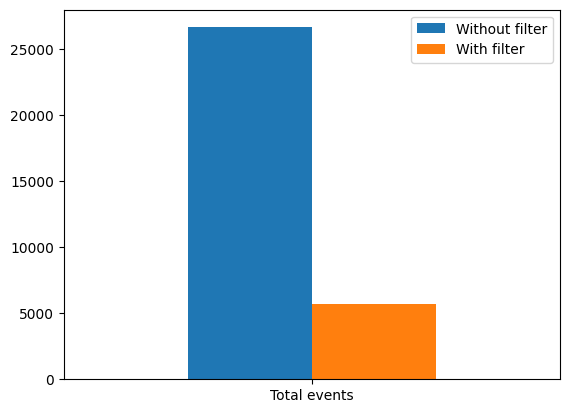

In [6]:
print("When appliying the filters, the number of events is reduced from " + str(em_dat_raw.shape[0] )+ " to " 
      + str(df_adjusted .shape[0]))
obs_effect = pd.DataFrame(columns=["Without filter", "With filter"])
obs_effect.loc["Total events"] = [em_dat_raw.shape[0], df_adjusted.shape[0]]
obs_effect.plot(kind = "bar").set_xticklabels(labels = ["Total events"], rotation = 0);

# Frequency modeling

In [7]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [8]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

#### Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [9]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "co2", 
            "population",
               "precip_deviation"]

df['square_ln_gdp_p'] =df['ln_gdp_pc'] **2

features_stand = []
for feature in features:
    features_stand.append(feature + '__standardized')

In [10]:
df.dropna(subset=features , inplace=True)
df = df.query('year > 1980')

#### Reconcile EMDAT and shapefile ISO codes

In [11]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [12]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [13]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'MNP, SGS, DMA, SHN, JAM, GRL, ASM, LIE, TUV, BLM, PSE, CUW, MAF, TCA, BHS, COM, ATF, KNA, GGY, IMN, SGP, UNK, GIB, MDV, MLT, SLB, SMR, LCA, CPV, VCT, VIR, FSM, ISR, ABW, VGB, NFK, SPM, VEN, VAT, KIR, PLW, GUM, NRU, LUX, HMD, TON, BHR, MCO, MHL, PRK, TTO, BRB, SXM, AIA, CYM, HKG, CYP, GRD, FRO, BMU, AND, QAT, PCN, STP, SYC, WLF, MAC, NIU, COK, FLK, MSR, JEY, IOT, PRI, ATG'

In [14]:
# Drop codes not in both
common_codes = set(world_iso).intersection(set(df_iso))

df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

In [15]:
# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

In [16]:
y = df[disasters].copy().astype(float)

# Assume years without observed disasters had no disasters.
# **THIS IS A TERRIBLE ASSUMPTION **
# but sampling is too onerous without it.
y_filled = y.fillna(0)

#### EDA

In [17]:
descriptive_stats_function(df =y_filled, varlist= ['hydrological_disasters'
                                                  ]).rename(
                                                    columns = {'hydrological_disasters': 'hydrological disasters'})

,hydrological disasters
count,5818.000000
mean,0.792369
std,1.833690
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,28.000000
kurtosis,54.004142
skewness,5.900220


<Axes: xlabel='hydrological_disasters', ylabel='Density'>

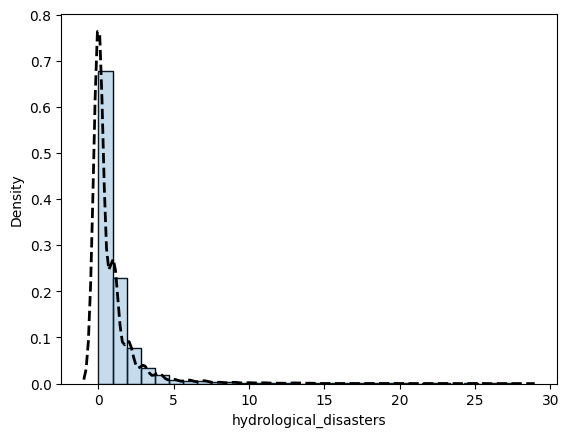

In [18]:
_plot_single_kde(data = (y_filled['hydrological_disasters']), leg_loc = 'upper right', set_title = False, add_sum_box = False )

# plt.savefig(here(eda_plots_path) / 'event_kden.png', format = 'png', bbox_inches='tight')

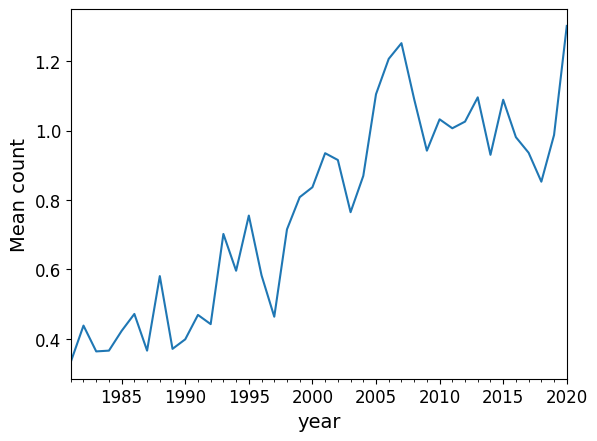

In [19]:
y_filled['hydrological_disasters'].groupby('year').mean().plot()

plt.ylabel('Mean count', fontdict= {'size': 14});
plt.xlabel('year', fontdict= {'size': 14});
plt.tick_params(axis='both', which='major', labelsize=12)

# plt.gca().xaxis.set_label_coords(0.5, -0.07)  # Adjust the coordinates as needed

# plt.savefig(here(eda_plots_path) / 'event_trend.png', format = 'png', bbox_inches='tight' );

In [20]:
descriptive_stats_function(df = df.dropna(subset=features) ,varlist= features)

,ln_population_density,ln_gdp_pc,co2,population,precip_deviation
count,5818.000000,5818.000000,5818.000000,5818.000000,5818.000000
mean,3.817885,8.200115,374.904914,40.728972,0.383073
std,1.326394,1.462496,21.316590,139.791279,173.889002
min,0.118925,5.104128,340.120000,0.118249,-1477.121000
25%,2.954218,7.076175,356.540000,3.619052,-69.707707
50%,4.024124,8.103448,373.450000,9.446310,-1.133408
75%,4.678044,9.228501,391.850000,27.926316,70.275374
max,7.152695,11.643949,414.210000,1411.100000,1576.264667
kurtosis,-0.139928,-0.870530,-1.118469,61.508511,8.778741
skewness,-0.412669,0.214114,0.170163,7.579622,0.067716


In [21]:
features_name_dict = {
    'ln_population_density': 'Log of population density',
    'ln_gdp_pc':'Log of GDP per capita',
    'co2':'Atmospheric CO2',
    'population': 'Population',
    'precip_deviation': 'Precipitation, deviation from trend',
    'square_ln_gdp_pc': 'Log of GDP per capita, squared'
}

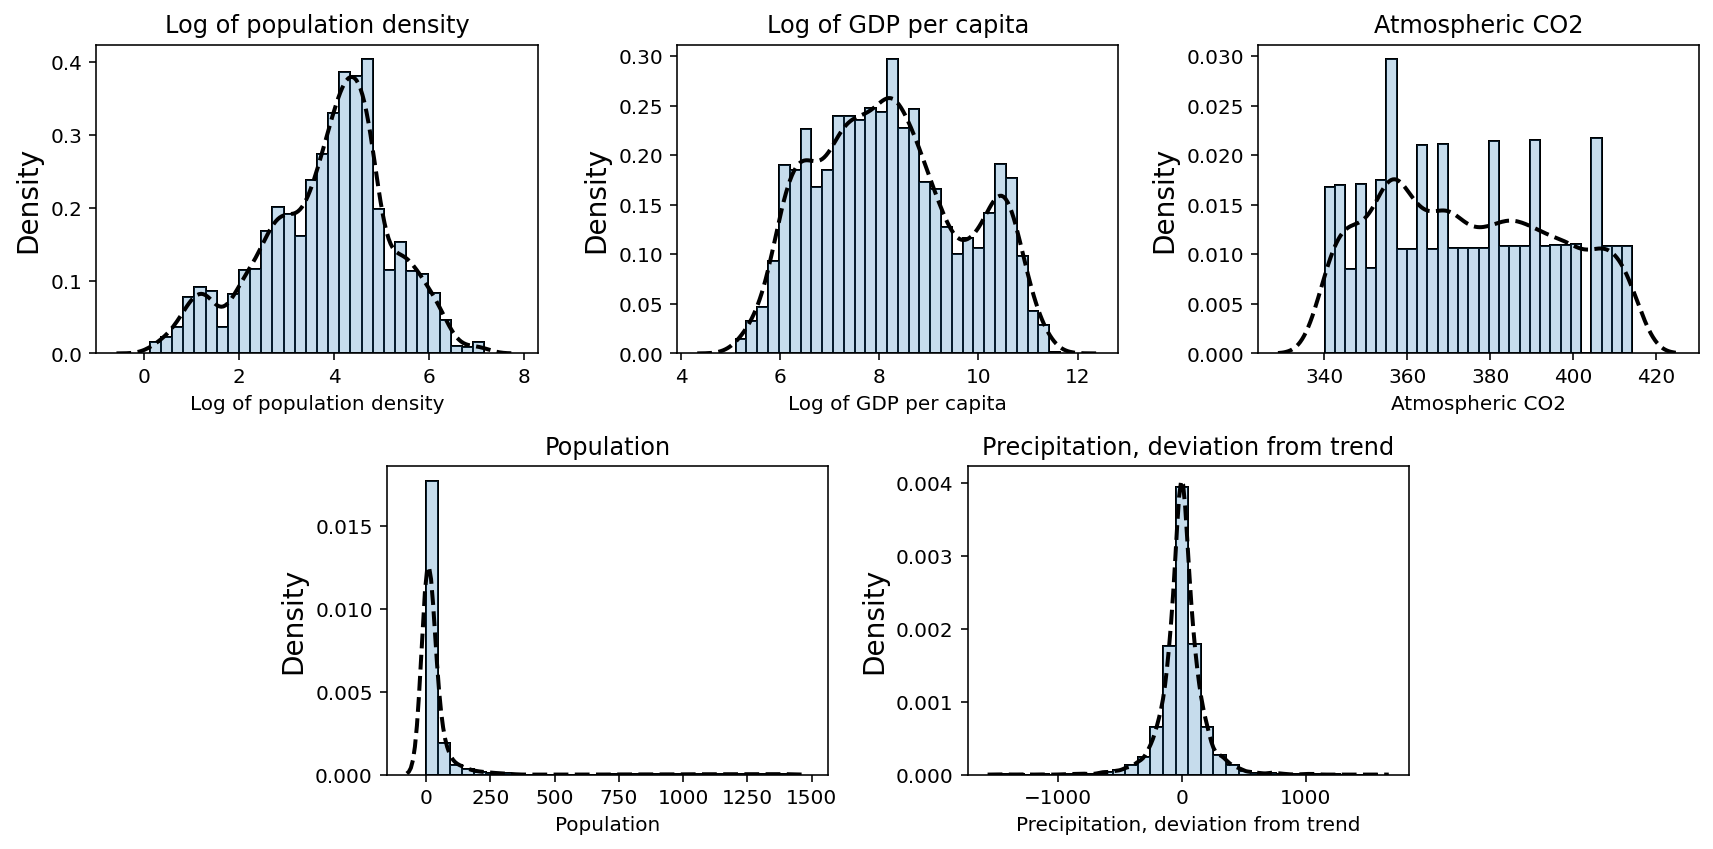

In [22]:
#Histogram and Kernel density for the number of events
df_ = df.dropna(subset=features)[features].rename(columns = features_name_dict)
plot1 = plot_descriptive(
    df = df_,
    n_cols = 3, bins= 30,
    color = "tab:blue",
    figsize = (12,6),
    add_sum_box = False
    )
plt.tight_layout()


# plt.savefig(here(eda_plots_path) / 'event_features_kden.png', format = 'png', bbox_inches='tight');

# Damage model

In [23]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [24]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

## Data loading and preparation

In [25]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [26]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [27]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_pc", 
            "precip_deviation", 
            "co2", 
            "population"]

In [28]:
df.dropna(subset=features, inplace=True)

## Reconcile EMDAT and shapefile ISO codes

In [29]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [30]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [31]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'MNP, SGS, DMA, SHN, JAM, GRL, ASM, LIE, TUV, BLM, PSE, CUW, MAF, TCA, BHS, COM, ATF, KNA, GGY, IMN, SGP, UNK, GIB, MDV, MLT, SLB, SMR, LCA, CPV, VCT, VIR, FSM, ISR, ABW, VGB, NFK, SPM, VEN, VAT, KIR, PLW, GUM, NRU, LUX, HMD, TON, BHR, MCO, MHL, PRK, TTO, BRB, SXM, AIA, CYM, HKG, CYP, GRD, FRO, BMU, AND, QAT, PCN, STP, SYC, WLF, MAC, NIU, COK, FLK, MSR, JEY, IOT, PRI, ATG'

In [32]:
emdat = load_emdat_data()

In [33]:
damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'})
                .replace({'Climatological':'climate',
                         'Hydrometereological':'hydro'}))

In [34]:
damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx = np.arange(x.shape[0])), 
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

# Get unique iso codes and years
_, codes = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes, years, classes, [0]], names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)), names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e3

In [35]:
df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e3

In [36]:
df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [37]:
# Adjusting damage data
# Importing cpi data
import pandas as pd
import pandas_datareader.data as pdr
import datetime

# Define the CPI series code for the US
cpi_series_code = 'CPIAUCNS'

# Define the date range
start_date = datetime.datetime(1913, 1, 1)  # CPI data starts from 1913
end_date = datetime.datetime(2025, 12, 31)  # Assuming we want data up to 2025

# Fetch CPI data from FRED
cpi_data = pdr.get_data_fred(cpi_series_code, start_date, end_date)

# Display the fetched data
cpi_2015 = cpi_data.loc['2015-12-01']['CPIAUCNS']
cpi_2025 = cpi_data.loc['2025-01-01']['CPIAUCNS']

In [38]:
X_damage = df_damage[features]
observed_damages = df_damage[['Total_Damage_Adjusted']] * (cpi_2025 / cpi_2015)

def standardize(x):
    return (x - x.mean()) / x.std()

X_damage_stand = X_damage.transform(standardize)

In [39]:
descriptive_stats_function(df =observed_damages, varlist= ['Total_Damage_Adjusted'])

,Total_Damage_Adjusted
count,2300.000000
mean,1721.119796
std,8233.071128
min,0.000000
25%,25.319665
50%,172.865941
75%,848.187614
max,261939.921228
kurtosis,507.949174
skewness,19.005457


<Axes: xlabel='Total_Damage_Adjusted', ylabel='Density'>

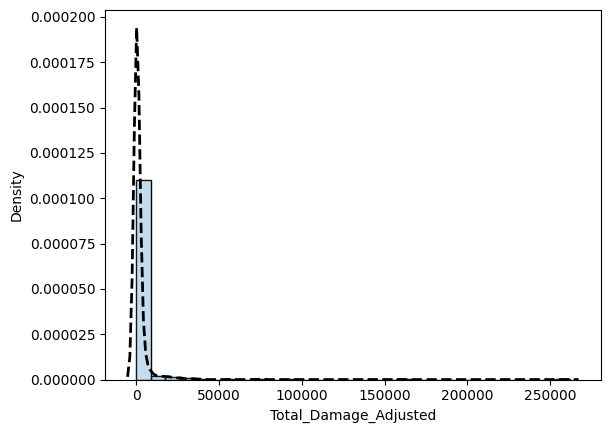

In [40]:
_plot_single_kde(data = (observed_damages['Total_Damage_Adjusted']), leg_loc = 'upper right', set_title = False,add_sum_box = False  )

# plt.savefig(here(eda_plots_path) / 'damages_kden.png', format = 'png', bbox_inches='tight')

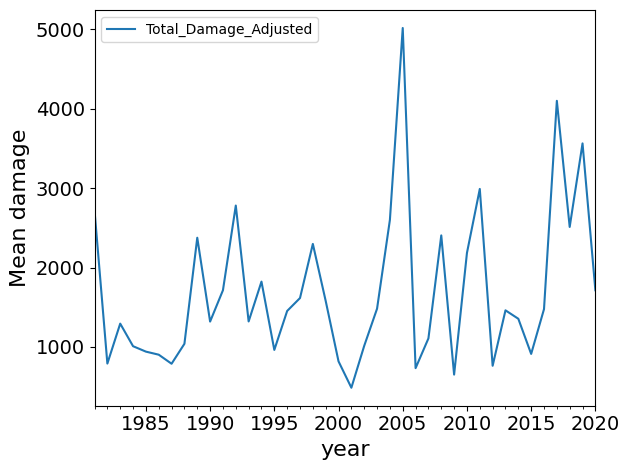

In [41]:
obs_dam_year = pd.merge(df_damage[['year']], observed_damages, left_index=True, right_index=True, how = 'left' )

# Plot
obs_dam_year.groupby('year').mean().plot()
plt.ylabel('Mean damage', fontdict= {'size': 16});
plt.xlabel('year', fontdict= {'size': 16});
plt.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
# plt.savefig(here(eda_plots_path) / 'damages_trend.png', format = 'png',);

In [42]:
descriptive_stats_function(df = X_damage_stand.dropna(subset=features) ,varlist= features)

,ln_population_density,ln_gdp_pc,square_ln_gdp_pc,precip_deviation,co2,population
count,2.300000e+03,2.300000e+03,2.300000e+03,2.300000e+03,2.300000e+03,2300.000000
mean,-1.235726e-17,-1.112154e-16,2.903957e-16,1.235726e-17,1.377835e-15,0.000000
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
min,-3.282578e+00,-2.458142e+00,-1.994043e+00,-4.693490e+00,-1.993954e+00,-0.687125
25%,-6.436854e-01,-6.766922e-01,-6.949326e-01,-3.688091e-01,-8.549447e-01,-0.638966
50%,2.690244e-01,-1.424088e-01,-2.117088e-01,-1.066447e-01,1.315927e-02,-0.513960
75%,7.869098e-01,5.713139e-01,5.011915e-01,2.707346e-01,8.570933e-01,-0.094173
max,2.075203e+00,2.246232e+00,2.476846e+00,5.112946e+00,1.736779e+00,2.145224
kurtosis,5.942310e-01,-4.734540e-01,-2.968026e-01,5.762283e+00,-1.054880e+00,-0.039754
skewness,-9.001727e-01,3.925356e-01,6.943855e-01,1.079068e+00,-5.854739e-02,1.336331


In [43]:
col_dict = { 'ln_population_density': 'Log of population density',
    'ln_gdp_pc':'Log of GDP per capita',
    'co2':'Atmospheric CO2',
    'population': 'Population',
    'precip_deviation': 'Precipitation, deviation from rolling mean',
    'square_ln_gdp_pc': 'Log of GDP per capita, squared'
}

In [44]:
'Precipitation, deviation from trend'

'Precipitation, deviation from trend'

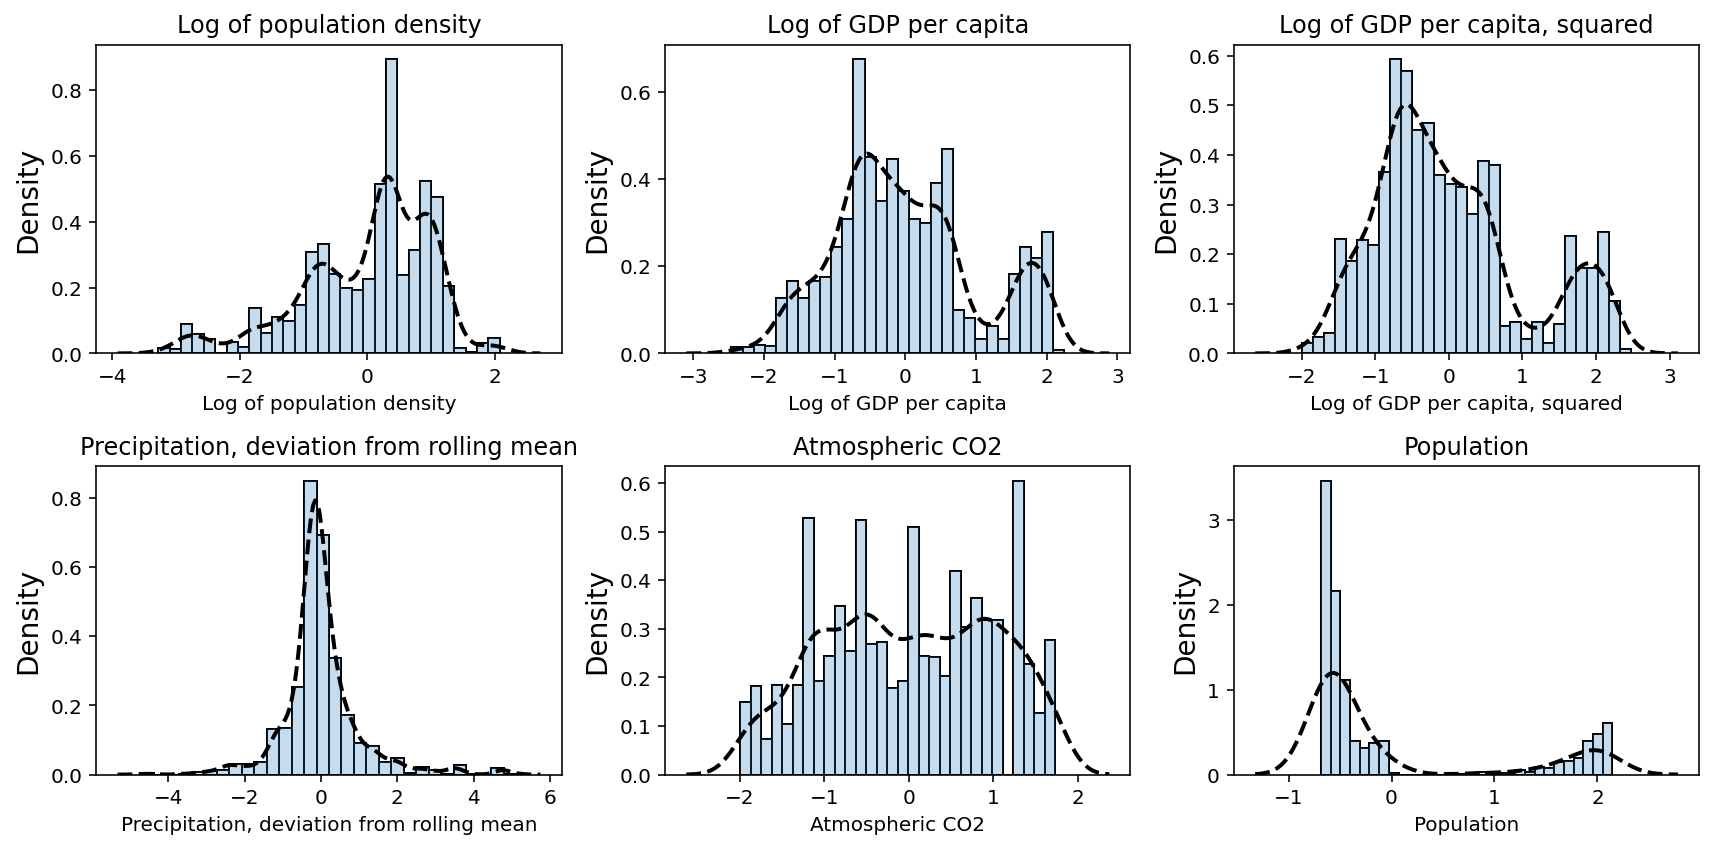

In [45]:
#Histogram and Kernel density for the number of events

df_ =  X_damage_stand.dropna(subset=features).rename(columns = col_dict)
plot1 = plot_descriptive(
    df = df_,
    n_cols = 3, bins= 30,
    color = "tab:blue",
    figsize = (12,6),
    add_sum_box = False
    
    )
plt.tight_layout()


# plt.savefig(here(eda_plots_path) / 'damage_features_kden.png', format = 'png', bbox_inches='tight');

In [46]:
(emdat['df_raw_filtered_adj'][['Start_Year', 'Total_Damage_Adjusted', 'ISO']]
 .dropna().sort_values(by = 'Total_Damage_Adjusted').query('Start_Year == "2005-01-01"'))

C:\Users\camil\AppData\Local\Temp\ipykernel_102060\459038339.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  .dropna().sort_values(by = 'Total_Damage_Adjusted').query('Start_Year == "2005-01-01"'))


,Start_Year,Total_Damage_Adjusted,ISO
15033,2005-01-01,31.0,SOM
15239,2005-01-01,229.0,NGA
15646,2005-01-01,284.0,PHL
15111,2005-01-01,384.0,THA
15032,2005-01-01,780.0,KEN
...,...,...,...
15408,2005-01-01,7801196.0,MEX
15395,2005-01-01,8113243.0,PAK
15409,2005-01-01,22311419.0,USA
15359,2005-01-01,24963826.0,USA


# Geospatial data modeling

In [47]:
#Load world bank shapefiles
world_shapefiles = load_shapefile('world', repair_ISO_codes=True)
import geopandas as gpd

## GTP query

In [48]:
from laos_gggi.data_functions.disaster_point_data import load_disaster_point_data

In [49]:
hydro_met_disasters_with_coords =  df_adjusted.dropna(subset= ['Latitude', 'Longitude']).shape[0]

print('Only ', hydro_met_disasters_with_coords, ' have coordinates data from 5818')

Only  864  have coordinates data from 5818


In [50]:
hydro_met_disasters_with_location =  df_adjusted.dropna(subset= ['Location']).shape[0]

print('Only ', hydro_met_disasters_with_location, ' have location data from 5818')

Only  5526  have location data from 5818


In [51]:
data_query = load_disaster_point_data()
data_query = (data_query.rename(columns ={'Disaster Subgroup': 'subgroup'})
                                       .query('subgroup in @hydro_met_list & disaster_class=="Hydrometereological"'))

In [52]:
hydro_met_disasters_with_coord_query= (data_query.shape[0])
hydro_met_disasters_with_coord_query

27771

In [53]:
df_adjusted_geo = gpd.GeoDataFrame(
                df_adjusted,
    geometry=gpd.points_from_xy(df_adjusted["Longitude"], df_adjusted["Latitude"]), crs="EPSG:4326"
            )

data_query_geo =  gpd.GeoDataFrame(
                data_query,
    geometry=gpd.points_from_xy(data_query["long"], data_query["lat"]), crs="EPSG:4326"
            )

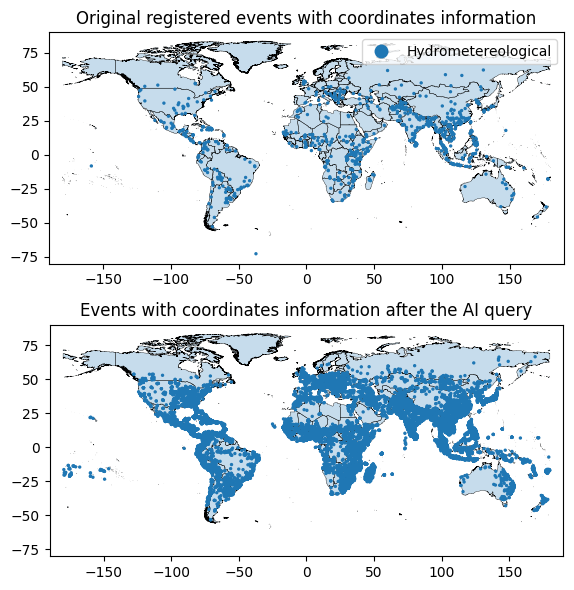

In [54]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 6))
gs = GridSpec(2, 1, height_ratios=[1, 1])  # Two rows, equal height

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# First subplot
world.plot(facecolor='tab:blue', alpha=0.25, ax=ax0)
world.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax0)
df_adjusted_geo.plot('disaster_class', markersize=2, ax=ax0, legend=True, c='#023047')
ax0.set_title('Original registered events with coordinates information')

# Second subplot
world.plot(facecolor='tab:blue', alpha=0.25, ax=ax1)
world.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax1)
data_query_geo.plot('disaster_class', markersize=2, ax=ax1, legend=False, c='#023047')

ax1.set_title('Events with coordinates information after the AI query')

for ax_ in [ax0, ax1]:
    ax_.set_xlim(-190, 190)
    ax_.set_ylim(-80, 90)

# Optional: manually add a shared legend if needed
# plt.legend(...)

plt.tight_layout()
# plt.savefig(here(eda_plots_path) / 'gpt_query_comp.png', format = 'png', bbox_inches='tight')
plt.show()



## Rivers

In [55]:
from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data

In [56]:
rivers = load_rivers_data(include_medium = True)

<Axes: >

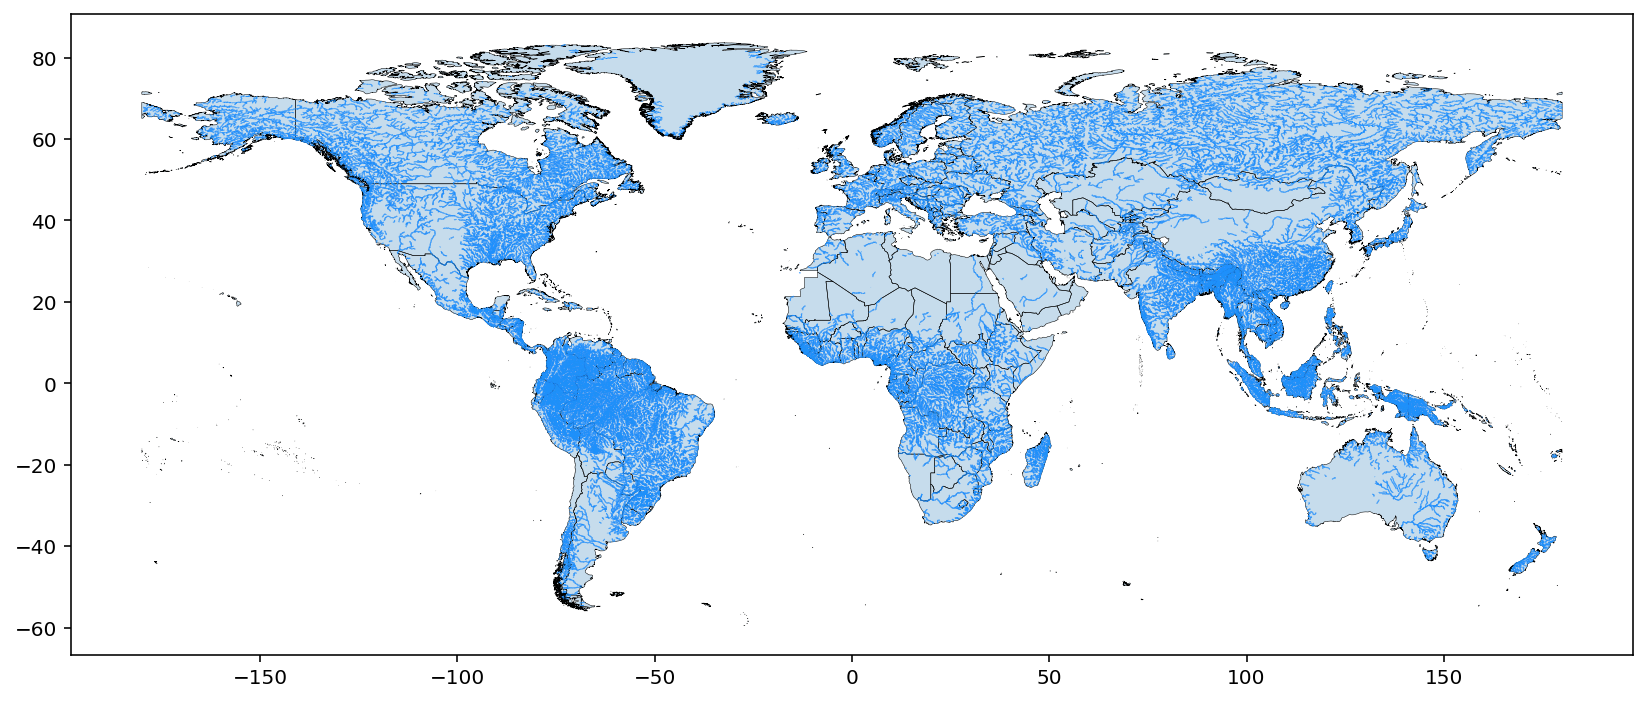

In [57]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
world.plot(facecolor='tab:blue', alpha=0.25, ax=ax)
world.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)

# plt.savefig(here(eda_plots_path) / 'world_rivers.png', format = 'png', bbox_inches='tight');

## Synthetic non-disaster generation


In [58]:
from laos_gggi.data_functions.disaster_point_data import (load_disaster_point_data, 
                    load_synthetic_non_disaster_points, load_grid_point_data, load_non_disaster_grid)

In [59]:
# Countries lists
laos_neigh = [
"KHM",  # Cambodia
"THA",  # Thailand
"LAO",  # Laos
"VNM",  # Vietnam  
]

ca_list = [
        # "BLZ",  # Belize
        "CRI",  # Costa Rica
        "SLV",  # El Salvador
        "GTM",  # Guatemala
        "HND",  # Honduras
        "NIC",  # Nicaragua
        "PAN"   # Panama]
]

In [60]:
############## Laos Neighboors ##############
# Load disasters and non-disasters
disasters = load_disaster_point_data()
# not_disasters = load_synthetic_non_disaster_points(by='country', multiplier=3)

not_disasters_laos_neigh = load_synthetic_non_disaster_points(by='country',
                                                       multiplier=15,
                                                       countries = laos_neigh, list_name = 'laos_neigh'      
                                                      )

# Merge data frames
merged_df_laos_neigh = pd.concat([not_disasters_laos_neigh.assign(is_disaster = 0), 
                       disasters.reset_index().assign(is_disaster=1)], 
                      ignore_index= True).query('ISO in @laos_neigh')
############## Central America ##############
# Load disasters and non-disasters
disasters = load_disaster_point_data()
# not_disasters = load_synthetic_non_disaster_points(by='country', multiplier=3)

not_disasters_ca = load_synthetic_non_disaster_points(by='country',
                                                       multiplier=15,
                                                       countries = ca_list , list_name = 'ca'
                                                    )

# Merge data frames
merged_df_ca = pd.concat([not_disasters_ca.assign(is_disaster = 0), 
                       disasters.reset_index().assign(is_disaster=1)], 
                      ignore_index= True).query('ISO in @ca_list')

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\synthetic_non_disasters_country_times_15_laos_neigh_.csv
Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\synthetic_non_disasters_country_times_15_ca_.csv


In [61]:
############## Laos neighboors map ##############
laos_neigh_map = world.query('ISO_A3_EH in @laos_neigh')

############## Central Americsa neighboors map ##############
# Filter La Isla del Coco in Costa Rica's map
# Define maps
ca_map = world.query('ISO_A3_EH in @ca_list')

############## Laos neighboors map ##############
threshold_latitude = 6
# Explode MultiPolygons into separate geometries
ca_map_exploded = ca_map.explode(index_parts=False)

# Filter out geometries south of the threshold latitude
ca_map_filtered = ca_map_exploded[
    ca_map_exploded.geometry.apply(lambda geom: geom.bounds[1] > threshold_latitude)
]


# Optional: Dissolve back to countries if needed
ca_map_filtered = ca_map_filtered.dissolve(by='ISO_A3_EH')

In [62]:
# Filter CA associated disasters
merged_df_ca =  merged_df_ca.query('long < -75 & lat >0')

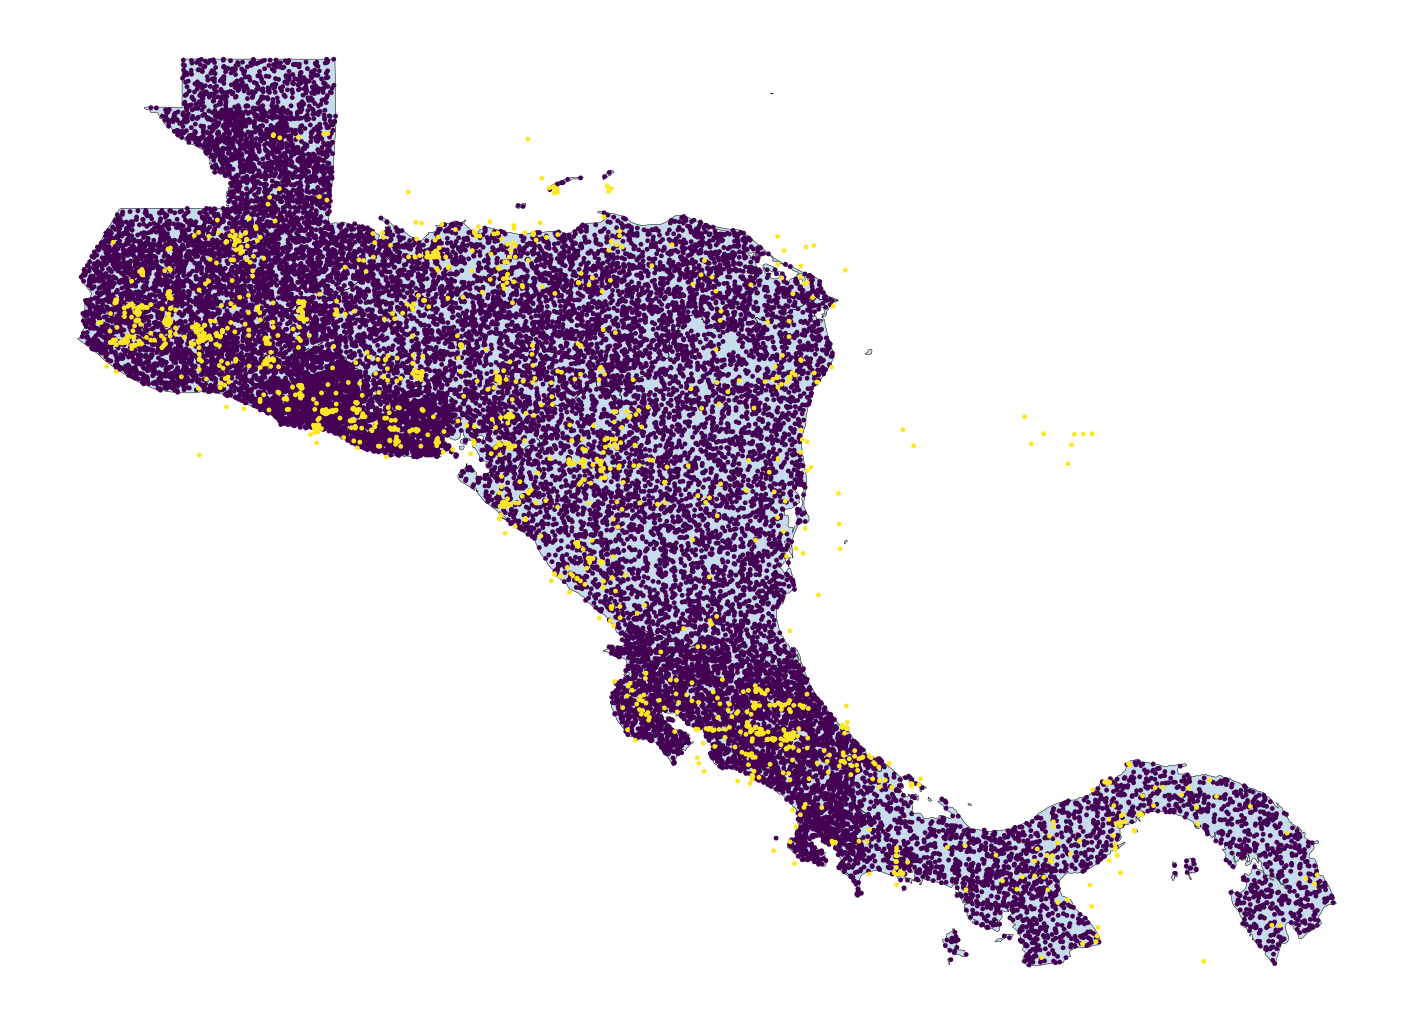

In [63]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
ca_map_filtered.plot(facecolor='tab:blue', alpha=0.25, ax=ax)
ca_map_filtered.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)

merged_df_ca.query('long < -75 & lat >6').plot("is_disaster",
                                      markersize=2, 
                                      ax=ax, 
                                      legend=False, 
                                      # categorical=True,
                                      cmap='viridis')
ax.axis('off')
# plt.title("Synthetic vs. real data")
# plt.savefig(here(eda_plots_path) / 'ca_real_synth_dis.png', format = 'png', bbox_inches='tight')
plt.show()

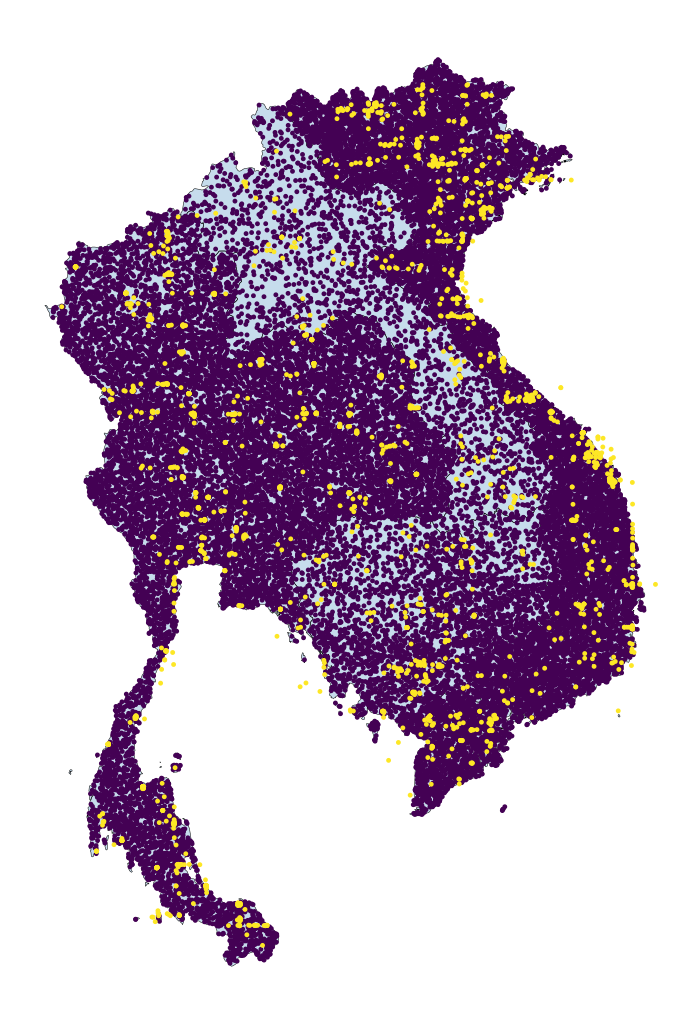

In [64]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
laos_neigh_map.plot(facecolor='tab:blue', alpha=0.25, ax=ax)
laos_neigh_map.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)

merged_df_laos_neigh.plot("is_disaster",
                                      markersize=2, 
                                      ax=ax, 
                                      legend=False, 
                                      # categorical=True,
                                      cmap='viridis')
ax.axis('off')
# plt.title("Synthetic vs. real data")
# plt.savefig(here(eda_plots_path) / 'laos_neigh_real_synth_dis.png', format = 'png', bbox_inches='tight')
plt.show()

## Central America geospatial data set

In [65]:
features_stand = ['is_disaster','log_distance_to_river__standardized',
 'log_distance_to_coastline__standardized',
 'Population__standardized',
 'co2__standardized',
 'precip_deviation__standardized',
 'dev_ocean_temp__standardized',
 'log_population_density__standardized',
 'log_gdp_per_cap__standardized',]

pd.set_option('display.float_format', '{:.2f}'.format)

In [66]:
ca_df_stand = pd.read_csv(here('data/geo_df_central_america.csv'))[features_stand]

In [67]:
descriptive_stats_function(df = ca_df_stand ,varlist= features_stand)

,is_disaster,log_distance_to_river__standardized,log_distance_to_coastline__standardized,Population__standardized,co2__standardized,precip_deviation__standardized,dev_ocean_temp__standardized,log_population_density__standardized,log_gdp_per_cap__standardized
count,22092.00,22092.00,22092.00,22092.00,22092.00,22092.00,22092.00,22092.00,22092.00
mean,0.04,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00
std,0.20,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.00,-10.09,-7.73,-1.31,-1.72,-1.60,-2.28,-1.59,-2.77
25%,0.00,-0.44,-0.45,-0.72,-0.77,-0.82,-0.73,-0.83,-0.68
50%,0.00,0.23,0.24,-0.30,-0.07,-0.15,-0.06,-0.05,-0.06
75%,0.00,0.68,0.74,0.53,0.56,0.76,0.94,0.80,0.64
max,1.00,2.38,1.29,2.72,2.21,2.44,1.96,1.83,2.79
kurtosis,18.78,3.95,4.13,0.36,-0.30,-0.53,-0.61,-1.13,-0.11
skewness,4.56,-1.55,-1.65,1.13,0.60,0.62,0.05,0.16,0.11


In [68]:
varnames_dict =  {'is_disaster': 'Is a real disaster',
'log_distance_to_river__standardized': 'Log distance to river',
'log_distance_to_coastline__standardized': 'Log distance to coast',
'Population__standardized': 'Population',
'co2__standardized': 'Atmospheric CO2',
'precip_deviation__standardized': 'Precipitation, deviation from trend',
'dev_ocean_temp__standardized': 'Ocean temperature, deviation from trend',
'log_population_density__standardized': 'Log population density',
'log_gdp_per_cap__standardized': 'Log GDP per capita'}

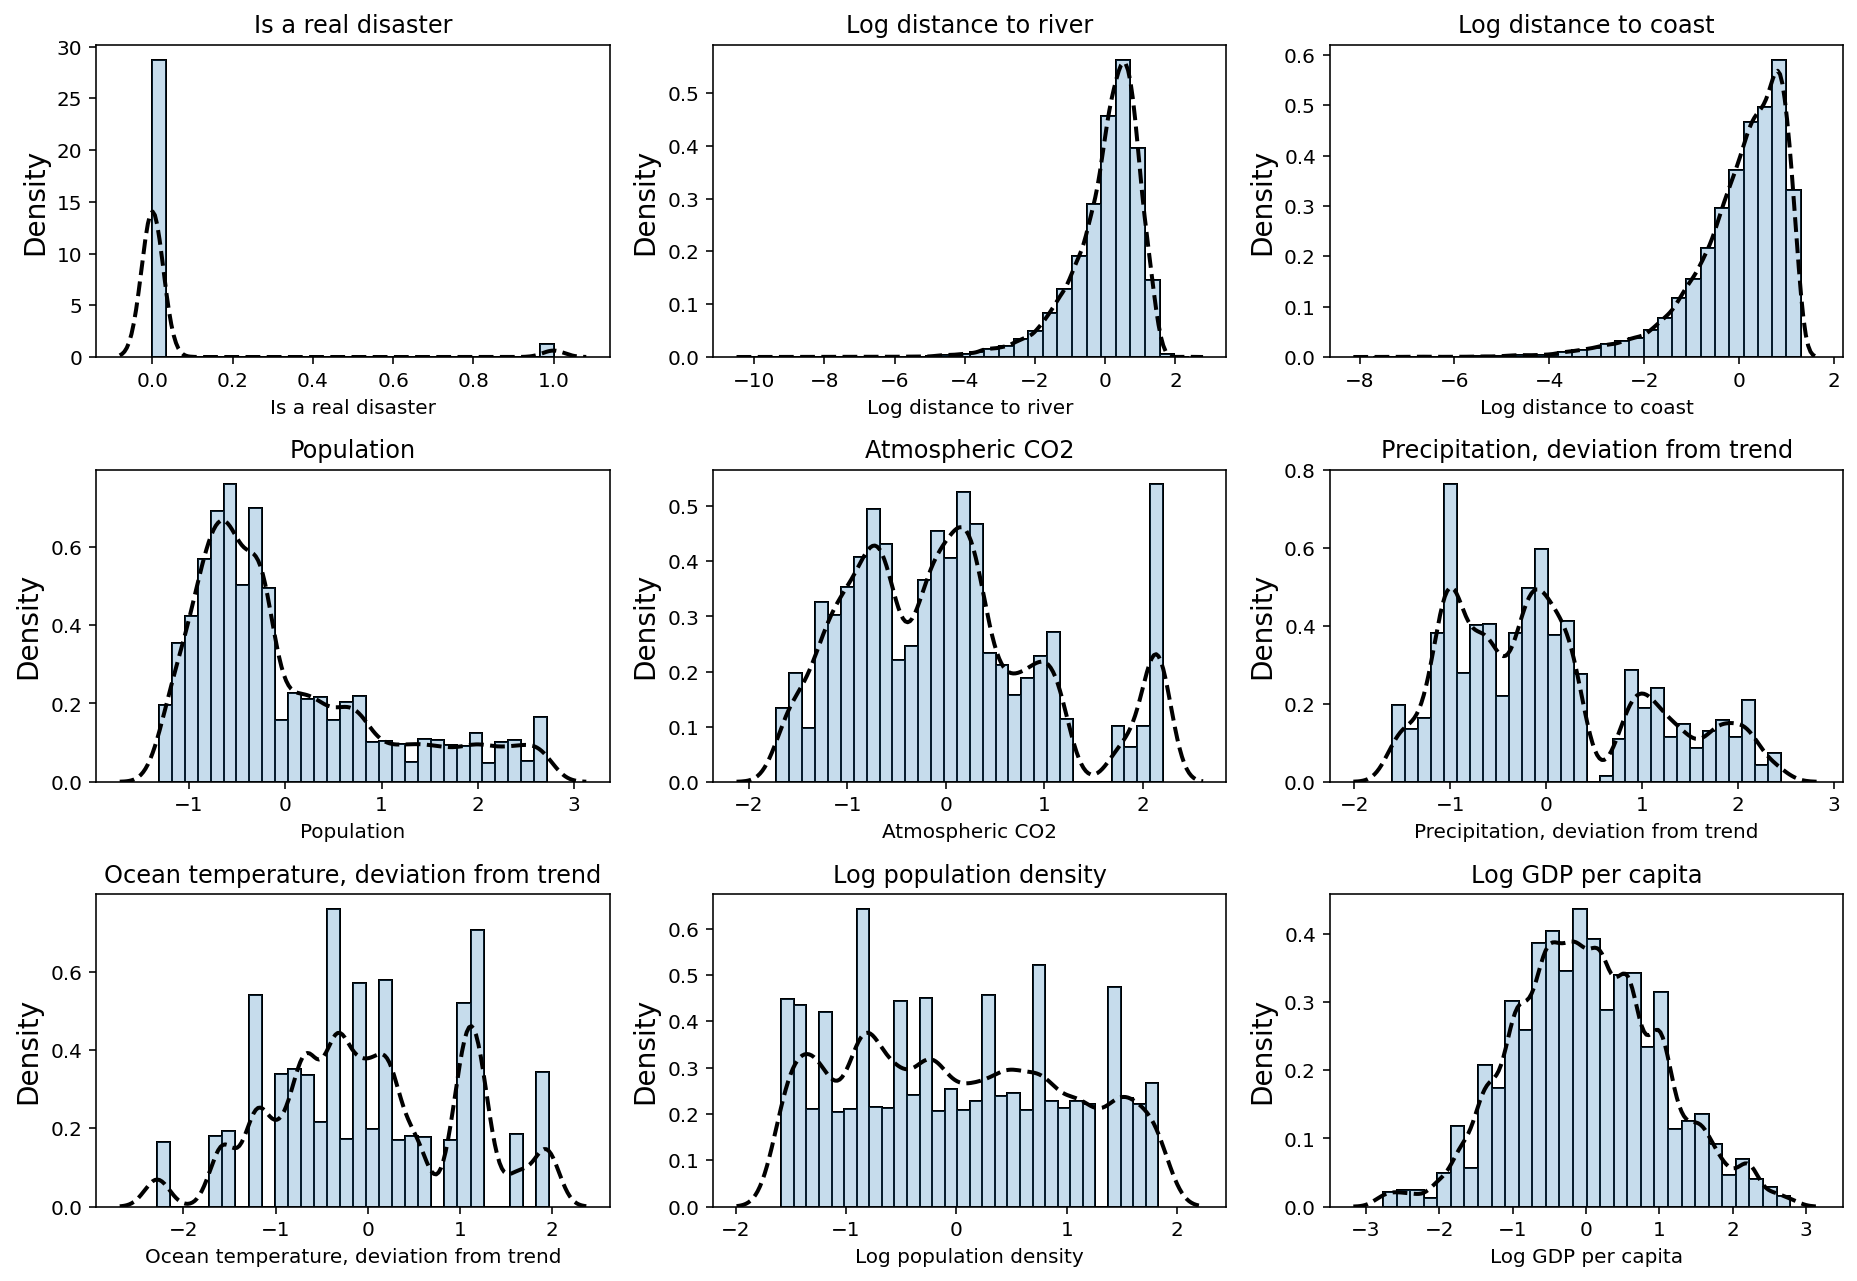

In [69]:
#Histogram and Kernel density for the number of events
df_ = ca_df_stand.rename(columns = varnames_dict)

plot1 = plot_descriptive(
    df = df_,
    n_cols = 3, bins= 30,
    color = "tab:blue",
    figsize = (13,9), 
    add_sum_box= False
    
    )
plt.tight_layout()


# plt.savefig(here(eda_plots_path) / 'geo_features_kden_ca.png', format = 'png', bbox_inches='tight');

## Laos neighboors geospatial data set

In [70]:
sea_df_stand  = pd.read_csv(here("data/sea_df_stand.csv"))[features_stand]

In [71]:
descriptive_stats_function(df = sea_df_stand ,varlist= features_stand)

,is_disaster,log_distance_to_river__standardized,log_distance_to_coastline__standardized,Population__standardized,co2__standardized,precip_deviation__standardized,dev_ocean_temp__standardized,log_population_density__standardized,log_gdp_per_cap__standardized
count,30030.00,30030.00,30030.00,30030.00,30030.00,30030.00,30030.00,30030.00,30030.00
mean,0.06,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,0.23,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.00,-7.92,-8.83,-2.35,-1.66,-2.48,-2.35,-3.44,-1.92
25%,0.00,-0.46,-0.49,-0.27,-0.88,-0.74,-0.71,-0.42,-0.81
50%,0.00,0.22,0.29,0.21,-0.07,-0.01,-0.09,-0.03,0.02
75%,0.00,0.69,0.75,0.61,0.80,0.65,0.91,0.82,0.82
max,1.00,1.66,1.30,1.49,1.86,2.81,1.95,1.28,1.62
kurtosis,13.13,3.35,3.36,0.44,-1.13,-0.00,-0.46,1.52,-1.11
skewness,3.89,-1.46,-1.57,-1.05,0.20,0.40,-0.01,-1.17,-0.17


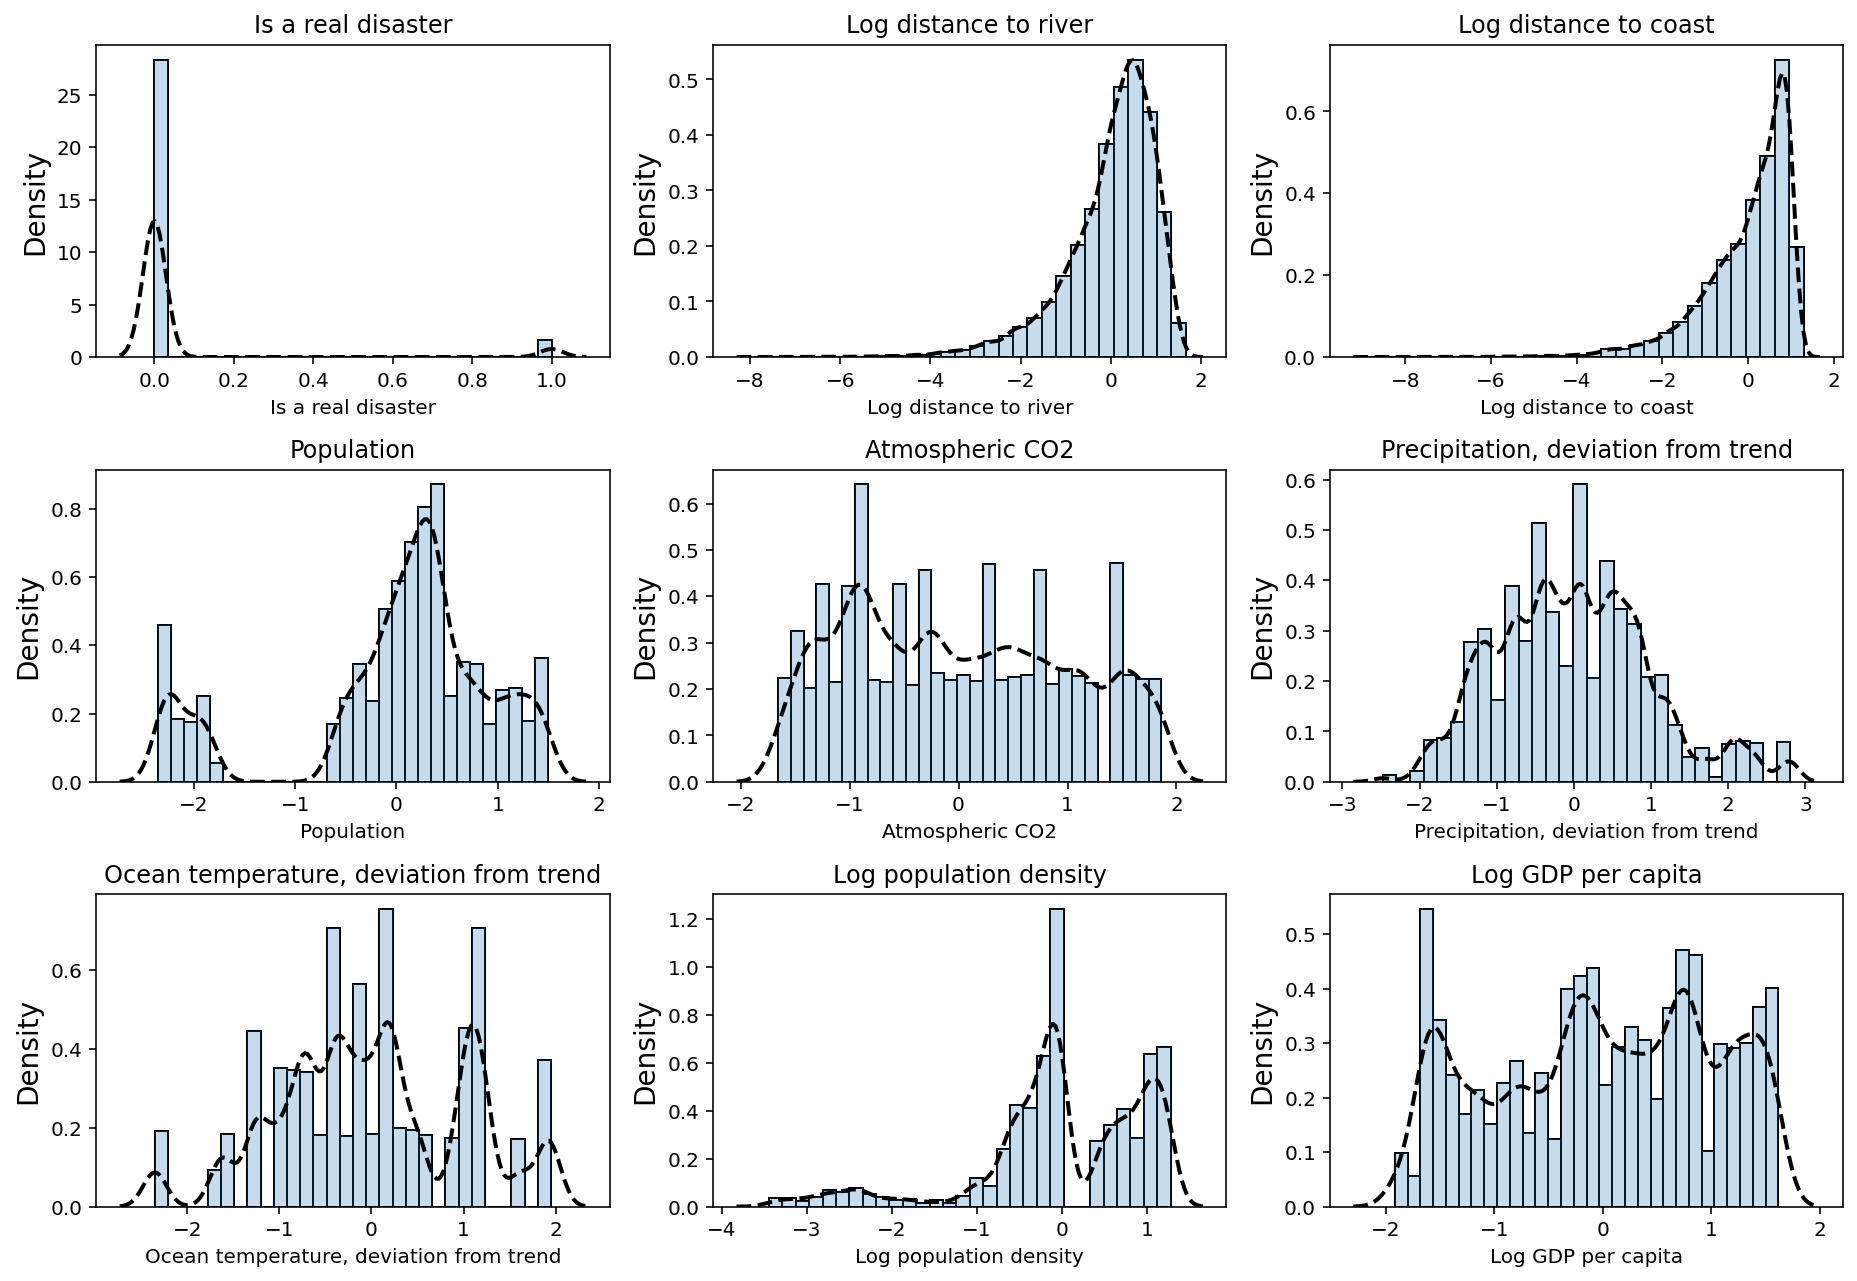

In [72]:
#Histogram and Kernel density for the number of events
df_ = sea_df_stand.rename(columns = varnames_dict)

plot1 = plot_descriptive(
    df = df_,
    n_cols = 3, bins= 30,
    color = "tab:blue",
      figsize = (13,9), 
    add_sum_box= False
    )
plt.tight_layout()

# plt.savefig(here(eda_plots_path) / 'geo_features_kden_laos_neigh.png', format = 'png', bbox_inches='tight');

### CRI grid

In [73]:
cr_grid = pd.read_csv(here('data/grid_cr.csv'), index_col=0)
cr_grid = gpd.GeoDataFrame(
                cr_grid,
    geometry = gpd.points_from_xy(cr_grid["long"], cr_grid["lat"]), crs="EPSG:4326"
            ).query('long < -75 & lat >6')

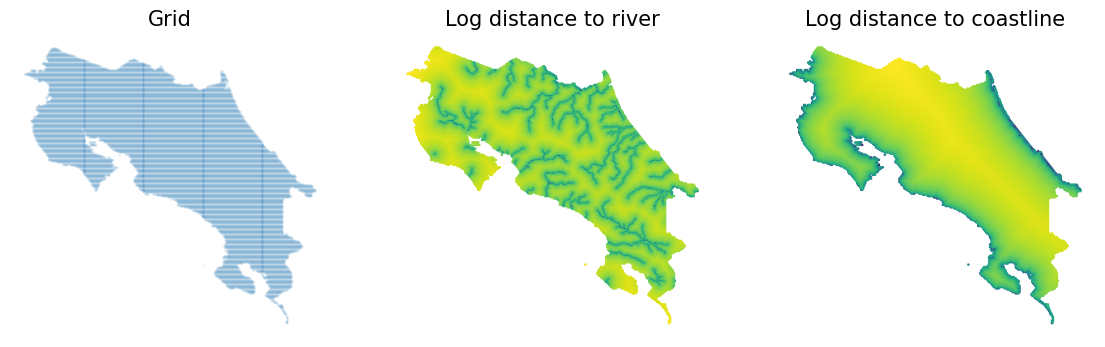

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 10))

cr_grid.plot(markersize=0.01, ax=axes[0], )
cr_grid.plot("log_distance_to_river__standardized", markersize=0.7, ax=axes[1])
cr_grid.plot("log_distance_to_coastline__standardized", markersize=0.7, ax=axes[2])

axes[0].set_title('Grid', fontsize=15)
axes[1].set_title('Log distance to river', fontsize=15)
axes[2].set_title('Log distance to coastline', fontsize=15)

# Remove grid and axes
for ax in axes:
    ax.set_axis_off()
# plt.savefig(here(eda_plots_path) / 'cr_grid.png', format = 'png', bbox_inches='tight');

### Laos grid

In [75]:
laos_grid = pd.read_csv(here("data/laos_point_grid.csv"), index_col=0)
laos_grid = gpd.GeoDataFrame(
                laos_grid,
    geometry = gpd.points_from_xy(laos_grid["long"], laos_grid["lat"]), crs="EPSG:4326"
            )

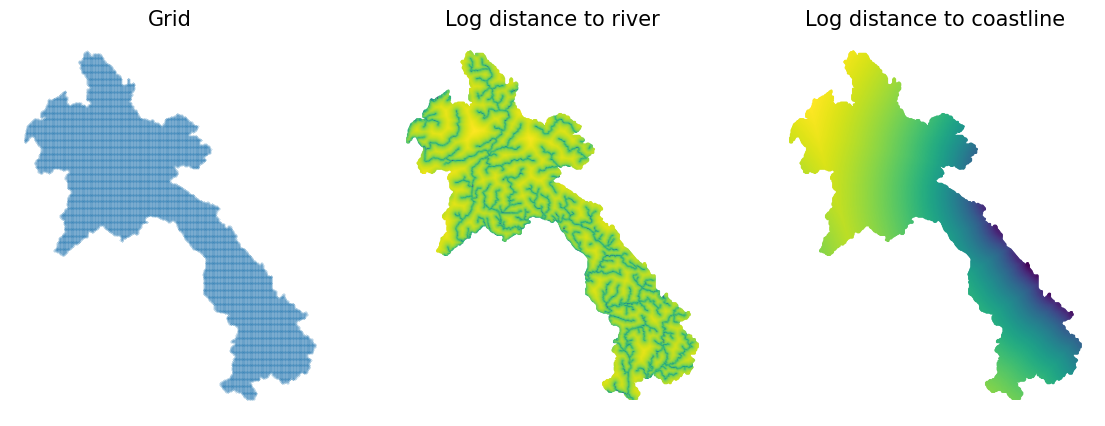

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(14, 10))

laos_grid.plot(markersize=0.01, ax=axes[0])
laos_grid.plot("log_distance_to_river__standardized", markersize=0.7, ax=axes[1])
laos_grid.plot("log_distance_to_coastline__standardized", markersize=0.7, ax=axes[2])

axes[0].set_title('Grid', fontsize=15)
axes[1].set_title('Log distance to river', fontsize=15)
axes[2].set_title('Log distance to coastline', fontsize=15)

# Remove grid and axes
for ax in axes:
    ax.set_axis_off()
# plt.savefig(here(eda_plots_path) / 'laos_grid.png', format = 'png', bbox_inches='tight');

# Time series data

In [77]:
import os
import sys 
from pyprojroot import here
sys.path.insert(0, str(here()))

import geopandas as gpd
from laos_gggi.plotting import configure_plot_style, prepare_gridspec_figure
from laos_gggi.data_functions.combine_data import load_wb_data, load_co2_data, load_ocean_heat_data, load_gpcc_data, load_all_data
from functools import partial, reduce

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import arviz as az

import pymc as pm
import pytensor.tensor as pt
from pymc_extras.statespace import BayesianETS
from pymc_extras.statespace.utils.data_tools import ImputationWarning
from functools import partial
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings(action='ignore', 
                        message='Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering',
                        category=ImputationWarning)
warnings.filterwarnings(action='ignore', message='compile_pymc was renamed to compile', category=FutureWarning)
warnings.filterwarnings(action='ignore', message='Skipping `CheckAndRaise` Op (assertion: PyTensor Assert failed!) as JAX tracing would remove it',
                        category=UserWarning)
warnings.filterwarnings(action='ignore', message='The RandomType SharedVariables',
                        category=UserWarning)
configure_plot_style(add_grid=True)

In [78]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

data = load_all_data()
df_raw = data['df_time_series'][['co2', 'Temp']]

# Compute country level precipitation deviation
# precip_deviation = (data["df_panel"][['precip']].groupby('ISO')
#                     .transform(lambda x: x - x.iloc[:30].mean())
#                     .rename(columns={'precip':'precip_deviation'}))
# data["df_panel"] = pd.merge( data["df_panel"], precip_deviation, left_index=True, right_index=True, how='left')

In [79]:
countries_df = pd.DataFrame()
for ISO in ['CRI', 'LAO']:
    iso_df = data["df_panel"].loc[ISO][["real_gdp", "Population", "precip"] ]
    new_cols = [x +'_' + ISO for x in list(iso_df.columns) ]
    iso_df.columns = new_cols
    
    countries_df = pd.concat([countries_df, iso_df], axis=1 )

df_merged = pd.merge(countries_df, df_raw, left_index=True, right_index= True, how = "right").query('year >1979')

In [80]:
# Transform gdp and population to millions
for col in ['real_gdp_LAO', 'real_gdp_CRI', 'Population_LAO',  'Population_CRI']:
    df_merged[col] = df_merged[col]/1e6

In [81]:
mod = {}
detrended = {}
for col in list(df_merged.columns):
    mod[col] = STL( df_merged[col].dropna() , period = 3).fit()
    detrended[col] = df_merged[col].dropna() - mod[col].trend

detrended = pd.DataFrame(detrended).query('year > 1979')

In [82]:
df_merged = df_merged.query('year > 1979')

In [83]:
# scale values
scaler = StandardScaler()
scaler.set_output(transform='pandas')
df = scaler.fit_transform(df_merged.map(np.log))

In [84]:
col_names_dict = {'real_gdp_CRI': 'Real GDP CRI', 'Population_CRI': 'Population CRI', 'precip_CRI': 'Precipitation CRI', 
                  'real_gdp_LAO': 'Real GDP LAO','Population_LAO': 'Population LAO', 'precip_LAO': 'Precipitation LAO', 'co2': 'Atmospheric CO2', 'Temp': 'Oceam temperature'}


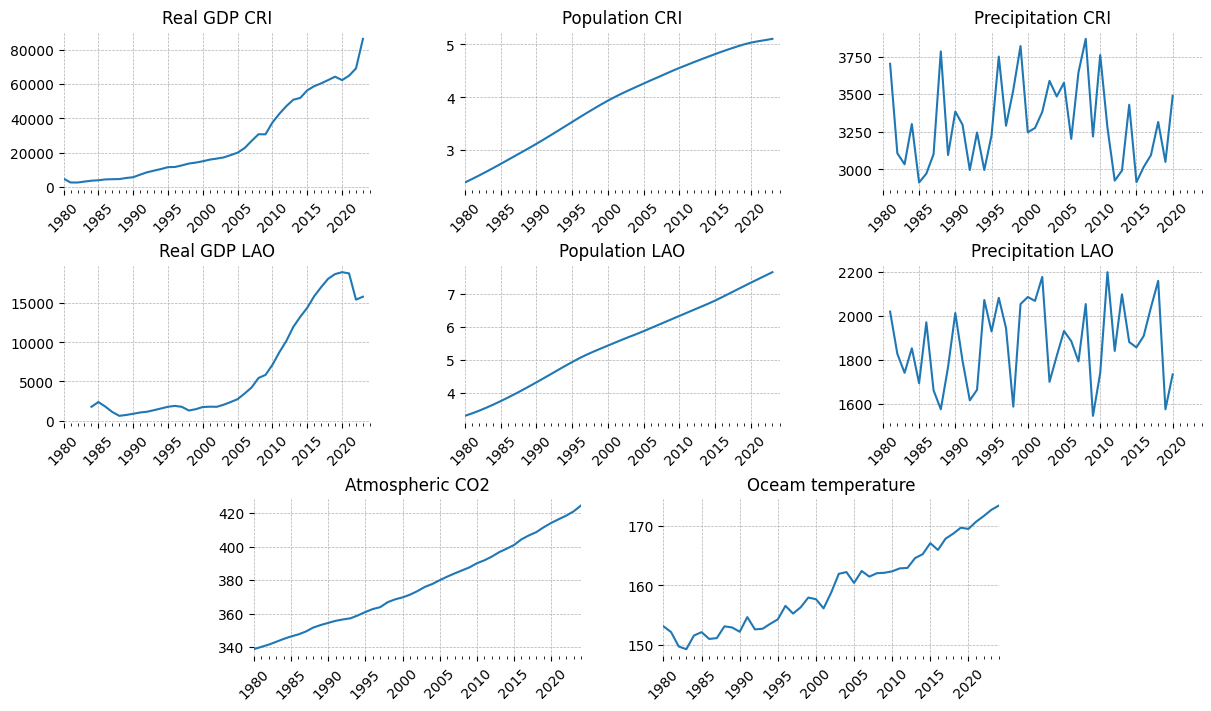

In [85]:
fig = plt.figure(figsize=(12, 7))
gs, locs = prepare_gridspec_figure(n_plots=detrended.shape[1], n_cols=3, figure=fig)

for loc, name in zip(locs, df_merged):
    axis = fig.add_subplot(gs[loc])
    df_merged[name].plot(ax=axis)
    axis.set_title(col_names_dict[name])
    axis.tick_params(axis='x', labelrotation=45)
    axis.set_xlabel('')  
# plt.savefig(here(eda_plots_path) / 'time_series_trend.png', format = 'png', bbox_inches='tight');

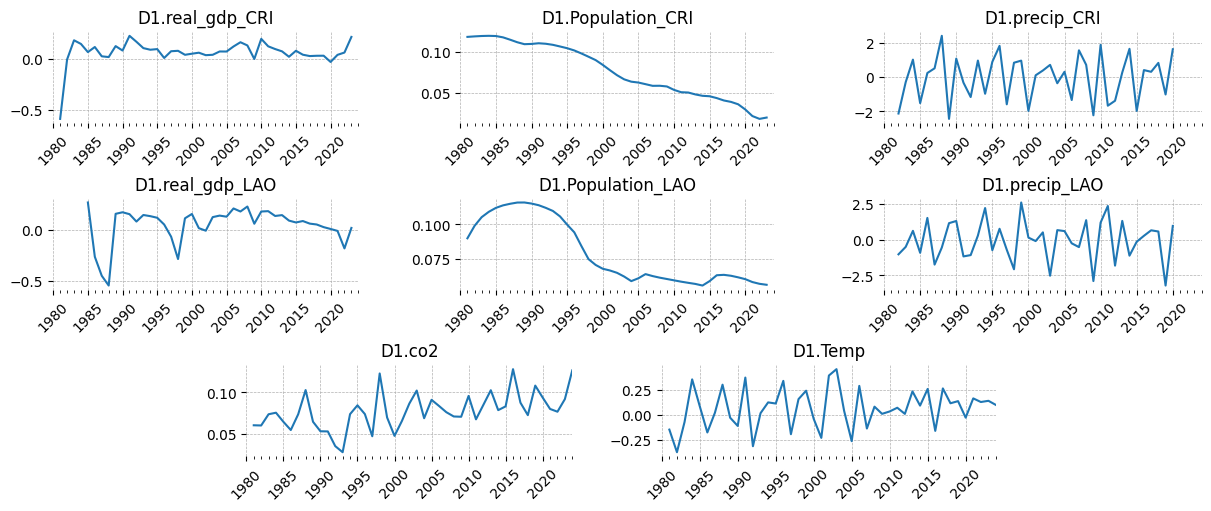

In [86]:
fig = plt.figure(figsize=(12, 5))
gs, locs = prepare_gridspec_figure(n_plots=df.shape[1], n_cols=3, figure=fig)
for loc, name in zip(locs, detrended):
    axis = fig.add_subplot(gs[loc])
    df[name].diff().plot(ax=axis)
    axis.set_title(f'D1.{name}')
    axis.tick_params(axis='x', labelrotation=45)
    axis.set_xlabel('')  
# plt.savefig(here(eda_plots_path) / 'time_series_diff_plot.png', format = 'png', bbox_inches='tight');

C:\Users\camil\AppData\Local\Temp\ipykernel_102060\2293036227.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


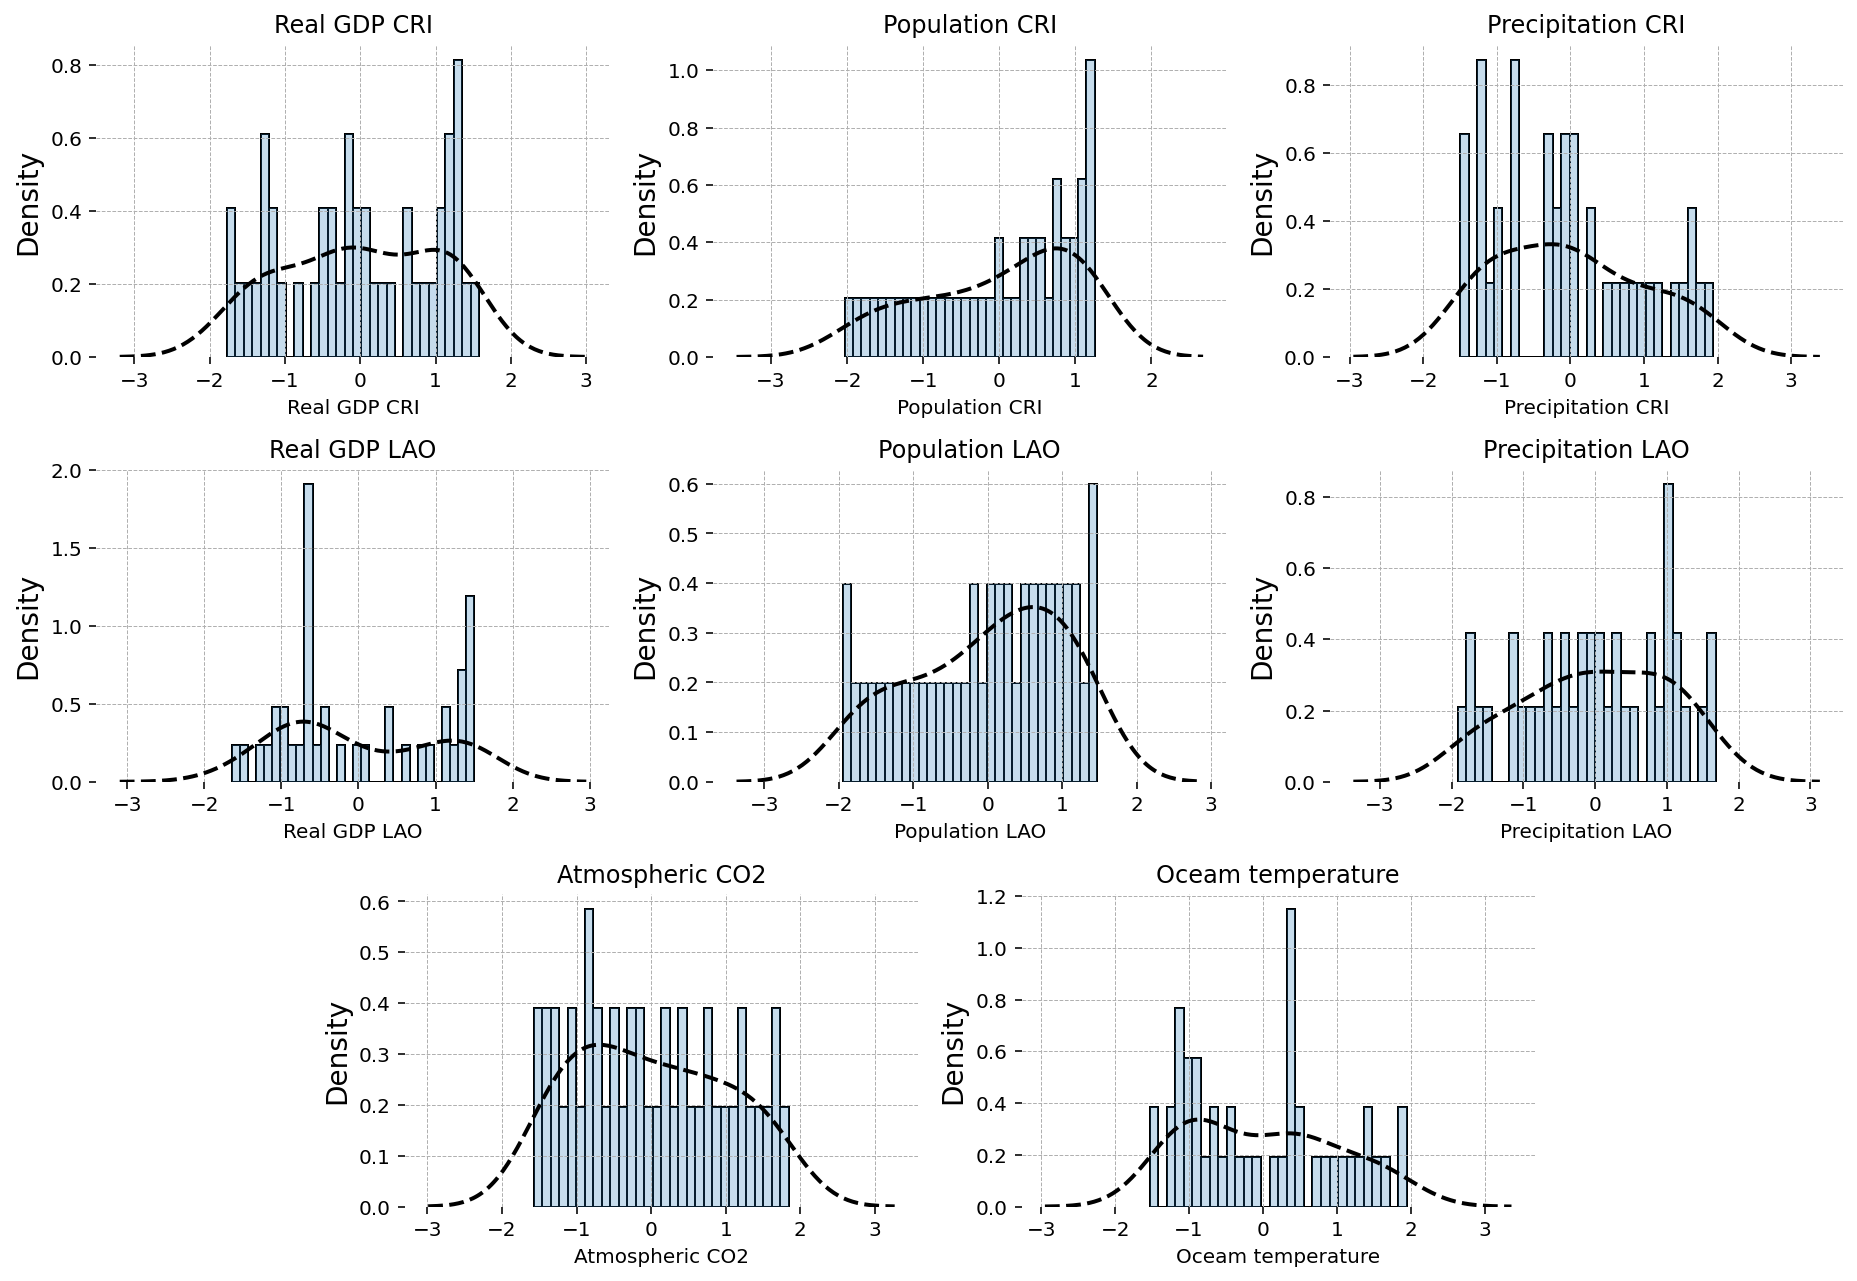

In [87]:
#Histogram and Kernel density for the number of events
df_ = df.rename(columns = col_names_dict )
plot1 = plot_descriptive(
    df = df_,
    n_cols = 3, bins= 30,
    color = "tab:blue",
      figsize = (13,9), 
    add_sum_box = False
    )
plt.tight_layout()

# plt.savefig(here(eda_plots_path) / 'time_series_k_den.png', format = 'png', bbox_inches='tight');

In [88]:
descriptive_stats_function(df = df ,varlist= list(df.columns))

,real_gdp_CRI,Population_CRI,precip_CRI,real_gdp_LAO,Population_LAO,precip_LAO,co2,Temp
count,44.00,44.00,40.00,40.00,44.00,40.00,45.00,45.00
mean,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01
min,-1.77,-2.03,-1.50,-1.64,-1.95,-1.92,-1.57,-1.53
25%,-0.85,-0.79,-0.81,-0.70,-0.77,-0.71,-0.83,-0.94
50%,-0.02,0.24,-0.07,-0.39,0.17,0.02,-0.10,-0.10
75%,1.02,0.88,0.72,1.11,0.83,0.93,0.82,0.73
max,1.58,1.26,1.94,1.50,1.47,1.68,1.85,1.95
kurtosis,-1.23,-0.99,-0.97,-1.43,-0.99,-0.97,-1.15,-1.11
skewness,-0.15,-0.52,0.32,0.27,-0.40,-0.21,0.20,0.30


    "Stat": "Statistic", 
    "is_dis": "Is real disaster", 
    "log_riv": "Log distance to river", 
    "log_coast": "Log distance to coast", 
    "Pop": "Population", 
    "co2": "Atmospheric CO2", 
    "prec": "Precipitation, deviation from trend", 
    "ocean_t": "Ocean Temperature, deviation from trend", 
    "pop_dens": "Log of population density", 
    "gdp_pc": "Log of GDP per capita"